In [1]:
from sklearn.svm import SVC
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np

In [2]:
datafolder = r'C:/Users/Luc/PycharmProjects/CognitiveMod/data/'

neuralResonseS2 = pd.read_csv(datafolder + 'NeuralResponses_S2.txt')
neuralResonseS2

,NeuralResponses1,NeuralResponses2,NeuralResponses3,NeuralResponses4,NeuralResponses5,NeuralResponses6,NeuralResponses7,NeuralResponses8,NeuralResponses9,NeuralResponses10,...,NeuralResponses91,NeuralResponses92,NeuralResponses93,NeuralResponses94,NeuralResponses95,NeuralResponses96,NeuralResponses97,NeuralResponses98,NeuralResponses99,NeuralResponses100
0,5.393451,-0.636023,6.335568,9.108956,11.613519,1.278504,4.786971,8.260211,4.286386,2.922307,...,5.650715,3.375554,-0.889826,4.543087,5.493405,4.878178,-1.038016,5.791518,3.572074,6.241944
1,1.881211,4.883093,4.066362,5.522948,4.198205,5.861862,3.551330,3.299976,5.211678,-0.593679,...,5.067750,4.277549,3.068203,0.047961,8.137466,3.040062,4.296345,-1.224776,2.059878,3.864727
2,7.867336,6.480074,6.126570,-0.569807,1.567609,6.100322,4.209071,-1.580498,7.199009,1.312698,...,3.624293,3.504290,0.668682,-2.015928,1.436734,0.153496,8.658812,5.323047,1.427597,9.327665
3,-0.305300,4.367771,4.707374,6.293705,-0.544161,6.558471,8.869285,8.839139,4.496178,-1.581211,...,9.519470,4.787807,10.753415,8.384328,5.020198,6.094759,7.088974,3.821286,0.327327,-1.202492
4,7.011726,5.677294,-2.438829,-2.282887,4.850484,8.424624,-2.236010,6.150107,5.798972,0.378117,...,6.741899,7.154679,6.925407,3.865209,5.460703,3.643401,3.203332,4.288550,0.499473,2.208482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,8.618008,8.957703,10.687370,1.818571,1.573860,0.739959,-2.278197,1.007752,1.737915,8.385795,...,7.781822,8.865388,4.904654,5.457162,0.248942,-0.607742,2.224388,4.504382,7.400503,4.540499
84,1.557556,8.864649,7.915436,-3.112754,2.099889,-0.001761,0.121782,8.659867,5.378939,1.455530,...,7.557770,3.962454,2.830549,0.552037,3.727102,3.305377,4.012138,1.068205,5.481976,0.648984
85,5.619675,1.733255,0.627722,1.663747,1.872093,4.801286,3.031536,1.054690,-2.639284,7.158154,...,3.379654,5.208166,1.836115,4.396669,0.398075,8.817739,1.755314,1.296945,4.306318,6.756433
86,3.590145,5.554768,-3.014509,9.709839,8.019519,2.400463,3.134800,3.576241,0.260598,9.753272,...,5.817889,10.605865,-1.600954,3.569827,4.882531,4.503030,9.581698,2.029941,0.126521,5.814288


In [31]:
neuralResAnimate = neuralResonseS2.iloc[:44].reset_index(drop=True)
neuralResInanimate = neuralResonseS2.iloc[44:88].reset_index(drop=True)


Train_X_ani = neuralResAnimate.iloc[:22].reset_index(drop=True)
Test_X_ani = neuralResAnimate.iloc[22:44].reset_index(drop=True)
Train_y_ani = [1] * 22
Test_y_ani = [1] * 22

Train_X_inani = neuralResInanimate.iloc[:22].reset_index(drop=True)
Test_X_inani = neuralResInanimate.iloc[22:44].reset_index(drop=True)
Train_y_inani = [-1] * 22
Test_y_inani = [-1] * 22

In [32]:
Train_X = pd.concat([Train_X_ani, Train_X_inani], axis=0, ignore_index=True)
Test_X = pd.concat([Test_X_ani, Test_X_inani], axis=0, ignore_index=True)
Train_y = Train_y_ani + Train_y_inani
Test_y = Test_y_ani + Test_y_inani
len(Train_X)

44

In [41]:


clf = SVC(kernel='linear')
clf.fit(Train_X, Train_y)
prediction = clf.predict(Test_X)
prediction

array([-1,  1,  1, -1,  1, -1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
       -1, -1,  1, -1,  1, -1, -1,  1, -1, -1,  1, -1, -1,  1, -1, -1, -1,
       -1, -1,  1, -1, -1,  1,  1, -1, -1,  1])

In [42]:
from collections import Counter

result = [a == b for a, b in zip(Test_y, prediction)]
counts = Counter(result)
print(counts)

Counter({True: 29, False: 15})


In [54]:
weights = clf.coef_
weights = weights[0]
first20Weights = weights[:20].tolist()
first20Weights

[-0.007004091387018923,
 -0.008101620259867902,
 0.023409047634930263,
 0.007889480483100262,
 -0.0004441583964866023,
 0.013998025973867493,
 0.0035674690740454843,
 0.01894394475771987,
 0.014613438044026391,
 -0.05531633470912789,
 -0.01473066689516242,
 0.007876746119527805,
 -0.031995183362239346,
 0.0029661596587570675,
 0.011018713069267695,
 -0.025697920362700685,
 0.03126167159762347,
 0.009904106951649064,
 0.008731557544911159,
 -0.0028136341105778253]

In [55]:
Test_X2 = Test_X.iloc[:, :20]
Test_X2

avg_test2 = Test_X2.mean().tolist()
avg_test2

[4.5819833755831825,
 4.695413389050571,
 4.576592079111854,
 4.933028612258511,
 4.490801895237351,
 4.252566355186342,
 4.0060229964145275,
 4.316868490317386,
 3.9702584155778555,
 5.140889794737352,
 5.0193575259910945,
 6.024907203314059,
 4.755323211730785,
 5.069884307936604,
 3.9516236590482565,
 5.001450265301359,
 4.335225994222304,
 4.711295547264439,
 3.960085003532352,
 4.476622620851166]

In [56]:
scatterPlotQ1 = pd.DataFrame({
    'Weight': first20Weights,
    'Response': avg_test2
})
scatterPlotQ1

,Weight,Response
0,-0.007004,4.581983
1,-0.008102,4.695413
2,0.023409,4.576592
3,0.007889,4.933029
4,-0.000444,4.490802
5,0.013998,4.252566
6,0.003567,4.006023
7,0.018944,4.316868
8,0.014613,3.970258
9,-0.055316,5.140890


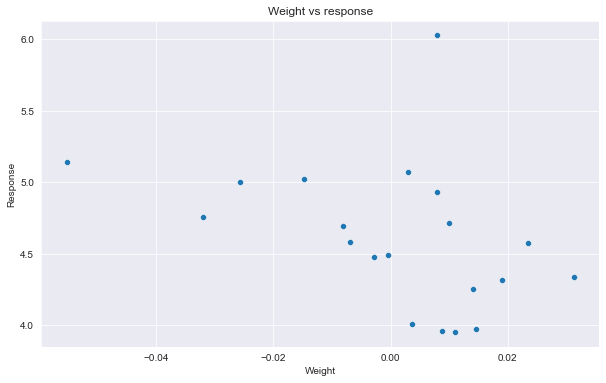

In [57]:
plt.figure(figsize=(10, 6))  # width=10, height=6 inches
sb.scatterplot(data=scatterPlotQ1, x='Weight', y='Response')

plt.xlabel('Weight')
plt.ylabel('Response')
plt.title('Weight vs response')

plt.show()

In [60]:
corr = np.corrcoef(first20Weights,avg_test2)
corr

array([[ 1.       , -0.4006589],
       [-0.4006589,  1.       ]])